In [6]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense

In [7]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(X_train.shape)
print(X_test.shape)

(60000, 28, 28)
(10000, 28, 28)


In [8]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [9]:
model = Sequential([
    Input(shape=(28, 28)),
    Flatten(),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

In [10]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [11]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    validation_split=0.1
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.9240 - loss: 0.2595 - val_accuracy: 0.9667 - val_loss: 0.1147
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.9672 - loss: 0.1077 - val_accuracy: 0.9707 - val_loss: 0.1040
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - accuracy: 0.9768 - loss: 0.0731 - val_accuracy: 0.9760 - val_loss: 0.0969
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.9818 - loss: 0.0566 - val_accuracy: 0.9713 - val_loss: 0.1001
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9862 - loss: 0.0429 - val_accuracy: 0.9790 - val_loss: 0.0825


In [12]:
y_pred = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [13]:
y_pred_classes = np.argmax(y_pred, axis=1)

In [14]:
misclassified = np.where(y_pred_classes != y_test)[0]

print("Total misclassified images:", len(misclassified))

Total misclassified images: 244


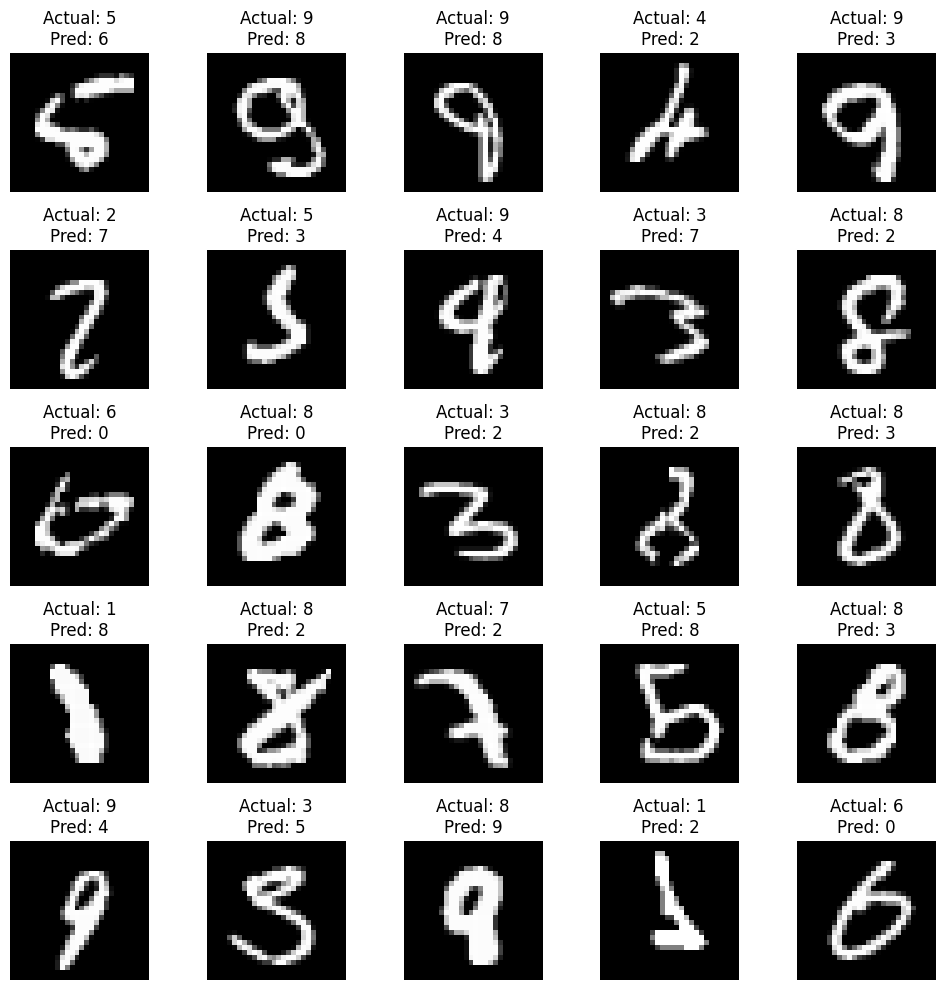

In [15]:
plt.figure(figsize=(10, 10))

for i, index in enumerate(misclassified[:25]):
    plt.subplot(5, 5, i + 1)
    plt.imshow(X_test[index], cmap="gray")
    plt.title(f"Actual: {y_test[index]}\nPred: {y_pred_classes[index]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [16]:
from collections import Counter

errors = [(y_test[i], y_pred_classes[i]) for i in misclassified]

error_counts = Counter(errors)

for (actual, predicted), count in error_counts.most_common(10):
    print(f"Actual {actual} → Predicted {predicted}: {count}")

Actual 9 → Predicted 4: 15
Actual 7 → Predicted 2: 14
Actual 5 → Predicted 3: 12
Actual 3 → Predicted 2: 11
Actual 6 → Predicted 0: 10
Actual 8 → Predicted 0: 8
Actual 5 → Predicted 6: 7
Actual 3 → Predicted 7: 7
Actual 8 → Predicted 2: 7
Actual 8 → Predicted 3: 7


In [17]:
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Flatten, Dense, Dropout

improved_model = Sequential([
    Input(shape=(28, 28)),
    Flatten(),
    Dense(256, activation="relu"),
    Dropout(0.2),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(10, activation="softmax")
])

In [18]:
improved_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [19]:
history_improved = improved_model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_split=0.1
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9163 - loss: 0.2774 - val_accuracy: 0.9655 - val_loss: 0.1155
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.9601 - loss: 0.1299 - val_accuracy: 0.9753 - val_loss: 0.0824
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.9701 - loss: 0.0956 - val_accuracy: 0.9800 - val_loss: 0.0705
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.9752 - loss: 0.0792 - val_accuracy: 0.9773 - val_loss: 0.0831
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.9770 - loss: 0.0707 - val_accuracy: 0.9792 - val_loss: 0.0724
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.9807 - loss: 0.0593 - val_accuracy: 0.9828 - val_loss: 0.0613
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.9826 - loss: 0.0543 - val_accuracy: 0.9828 - val_loss: 0.0674
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9851 - loss:

In [20]:
improved_loss, improved_accuracy = improved_model.evaluate(
    X_test,
    y_test
)

print("Improved Model Accuracy:", improved_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9802 - loss: 0.0821
Improved Model Accuracy: 0.9801999926567078


In [21]:
improved_model.save("mnist_improved_model.keras")

In [22]:
import os

print(os.path.exists("mnist_improved_model.keras"))

True


In [23]:
improved_predictions = improved_model.predict(X_test)

improved_pred_classes = np.argmax(improved_predictions, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [24]:
improved_misclassified = np.where(
    improved_pred_classes != y_test
)[0]

print("Total misclassified images:", len(improved_misclassified))

Total misclassified images: 198


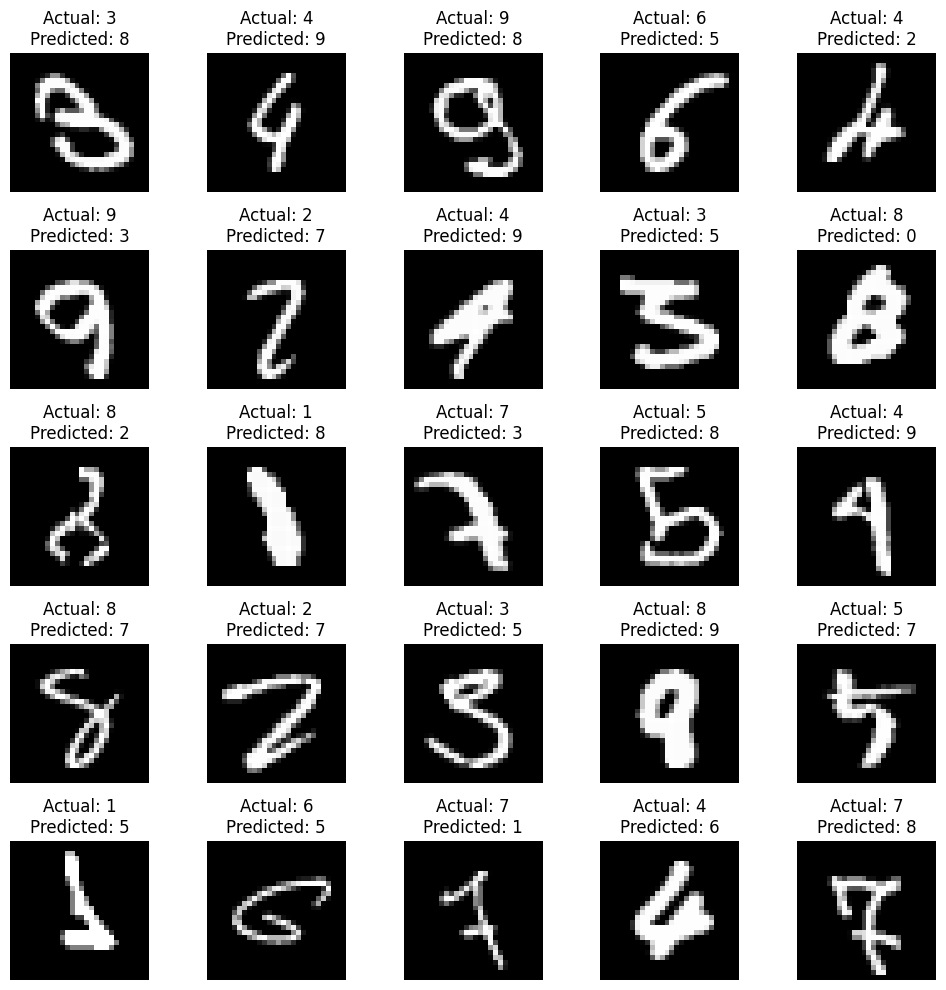

In [25]:
plt.figure(figsize=(10, 10))

for i, index in enumerate(improved_misclassified[:25]):
    plt.subplot(5, 5, i + 1)
    plt.imshow(X_test[index], cmap="gray")
    plt.title(
        f"Actual: {y_test[index]}\n"
        f"Predicted: {improved_pred_classes[index]}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

In [26]:
from sklearn.metrics import confusion_matrix, classification_report

improved_cm = confusion_matrix(y_test, improved_pred_classes)

print(improved_cm)

[[ 973    0    0    0    1    1    2    1    2    0]
 [   0 1125    1    1    0    2    2    1    3    0]
 [   6    1  990    4    2    0    5   13   10    1]
 [   0    0    1  980    1   10    0    5    4    9]
 [   2    0    4    0  945    0    7    3    0   21]
 [   2    0    0    1    0  883    3    1    1    1]
 [   2    2    0    1    1    7  944    0    1    0]
 [   1    3    2    2    0    0    0 1013    2    5]
 [   2    0    2    2    1    3    1    3  956    4]
 [   1    2    0    1    2    4    0    4    2  993]]


In [27]:
print(classification_report(y_test, improved_pred_classes))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.99      0.96      0.97      1032
           3       0.99      0.97      0.98      1010
           4       0.99      0.96      0.98       982
           5       0.97      0.99      0.98       892
           6       0.98      0.99      0.98       958
           7       0.97      0.99      0.98      1028
           8       0.97      0.98      0.98       974
           9       0.96      0.98      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000

